In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import openpyxl
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print('✅ Import xong!')

✅ Import xong!


In [11]:
# BƯỚC 1: ĐỌC FILE
file_path = 'TỔNG HỢP ĐIỂM K58KTP.xlsx'
raw_df = pd.read_excel(file_path, header=None, nrows=20)
header_idx = 0
for i, row in raw_df.iterrows():
    rs = row.astype(str).str.upper()
    if any('STT' in v or 'HỌ' in v or 'TÊN' in v or 'MÃ' in v for v in rs):
        header_idx = i; break
df = pd.read_excel(file_path, header=header_idx)
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')
print(f'🎯 Dòng tiêu đề: {header_idx+1} | Dữ liệu: {df.shape[0]} dòng x {df.shape[1]} cột')
display(df.head(3))

🎯 Dòng tiêu đề: 1 | Dữ liệu: 55 dòng x 74 cột


,TỔNG HỢP ĐIỂM\n(Từ kỳ 1 năm nhất - hết kỳ 2 năm 4)\n(Mỗi sv tự nhập Điểm TK (4)),Unnamed: 1,STT,1,2,3,4,5,6,7,...,62,63,64,65,66,67,68,69,70,71
0,NaN,NaN,MSSV,K225480106002,K225480106095,K225510201001,K225480106082,K225480106001,K225480106100,K225480106008,...,K225480106062,K225480106064,K225480106065,K225480106069,K225480106070,K225480106067,K225480106068,K225480106075,K225480106074,K225480106073
1,NaN,NaN,Tên Sinh Viên,Nguyễn Tuấn Anh,Nguyễn Tuấn Anh,Bùi Ngọc Anh,Vũ Việt Anh,Lê Tuấn Anh,Lý Văn Cường,Nguyễn Khánh Duy,...,Nguyễn Văn Thứ,Hoàng Thị Xuân Trang,Lê Quốc Trung,Lê Ngọc Tú,Nguyễn Đức Anh Tú,Nguyễn Đình Tú,Vũ Đức Tú,Nguyễn Đức Việt,Nguyễn Hoàng Việt,Lương Hoàng Việt
2,STT,Mã Môn học,Tên Môn học,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# BƯỚC 2: XỬ LÝ DỮ LIỆU
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == object:
        t = pd.to_numeric(df_clean[col].astype(str).str.replace(',','.'), errors='coerce')
        if t.notna().mean() > 0.4:
            df_clean[col] = t
skip = ['STT','MÃ','ID']
num_cols = df_clean.select_dtypes(include=[np.number]).columns
score_cols = [c for c in num_cols if not any(s in str(c).upper() for s in skip)]
df_clean[score_cols] = df_clean[score_cols].fillna(0)
df_clean['Điểm Trung Bình'] = df_clean[score_cols].mean(axis=1)
print(f'🔢 Cột điểm ({len(score_cols)}): {score_cols}')

🔢 Cột điểm (64): ['TỔNG HỢP ĐIỂM\n(Từ kỳ 1 năm nhất - hết kỳ 2 năm 4)\n(Mỗi sv tự nhập Điểm TK (4))', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 53, 54, 55, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71]


In [13]:
# BƯỚC 3: PHÂN CỤM
X = df_clean[score_cols].values
Z = linkage(X, method='ward')
df_clean['Cluster_ID'] = fcluster(Z, 3, criterion='maxclust')
m = df_clean.groupby('Cluster_ID')['Điểm Trung Bình'].mean().sort_values(ascending=False)
lmap = {cid: lbl for (cid,_),lbl in zip(m.items(),['Nhóm Xuất Sắc 🥇','Nhóm Khá/Tốt 🥈','Nhóm Cần Cố Gắng 🥉'])}
df_clean['Nhóm Học Lực'] = df_clean['Cluster_ID'].map(lmap)
df_clean.drop(columns=['Cluster_ID'], inplace=True)
other = [c for c in df_clean.columns if c not in ['Nhóm Học Lực','Điểm Trung Bình']]
df_clean = df_clean[['Nhóm Học Lực','Điểm Trung Bình'] + other]
print('✨ Phân cụm xong!')
display(df_clean[['Nhóm Học Lực','Điểm Trung Bình']].head(10))

✨ Phân cụm xong!


,Nhóm Học Lực,Điểm Trung Bình
0,Nhóm Cần Cố Gắng 🥉,0.000000
1,Nhóm Cần Cố Gắng 🥉,0.000000
2,Nhóm Cần Cố Gắng 🥉,0.000000
3,Nhóm Xuất Sắc 🥇,2.751562
4,Nhóm Xuất Sắc 🥇,2.835938
5,Nhóm Xuất Sắc 🥇,2.650000
6,Nhóm Xuất Sắc 🥇,2.970312
7,Nhóm Xuất Sắc 🥇,2.904687
8,Nhóm Xuất Sắc 🥇,3.189062
9,Nhóm Xuất Sắc 🥇,3.284375


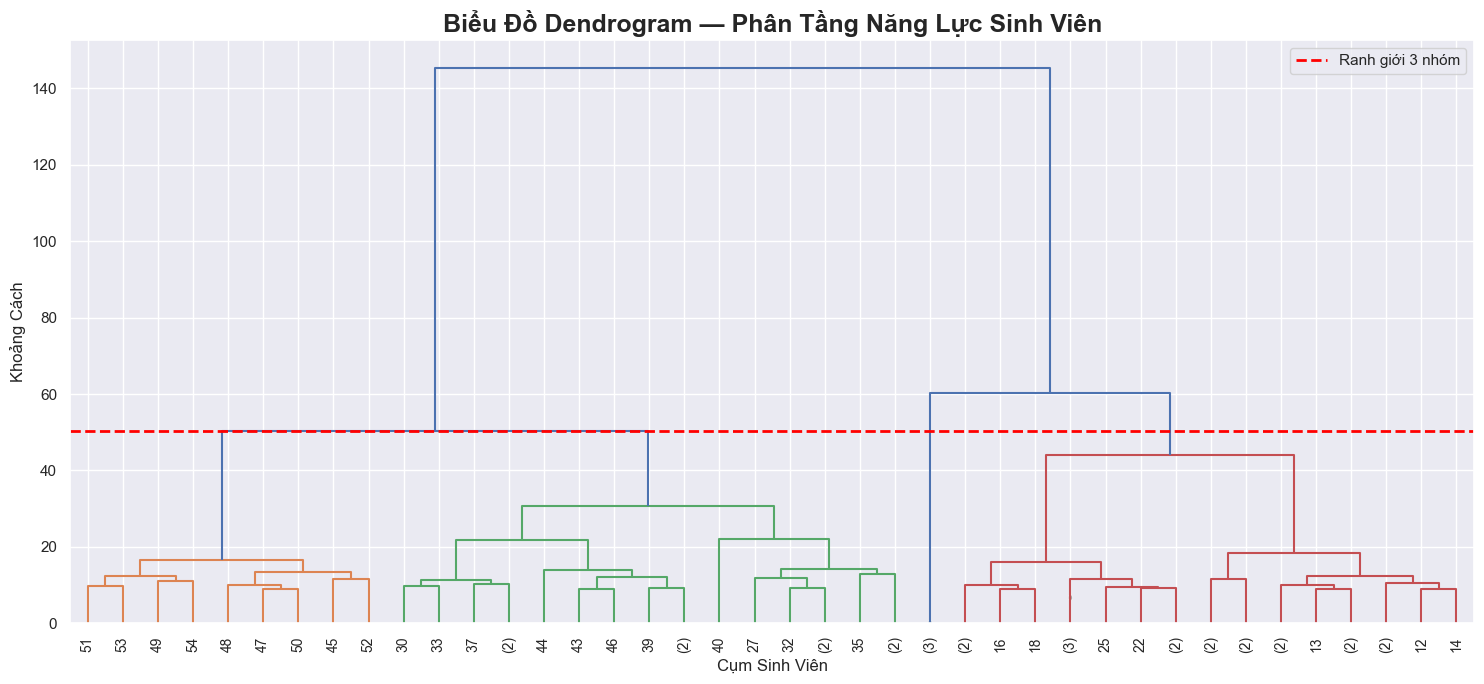

📸 Đã lưu Biểu đồ 1: Dendrogram


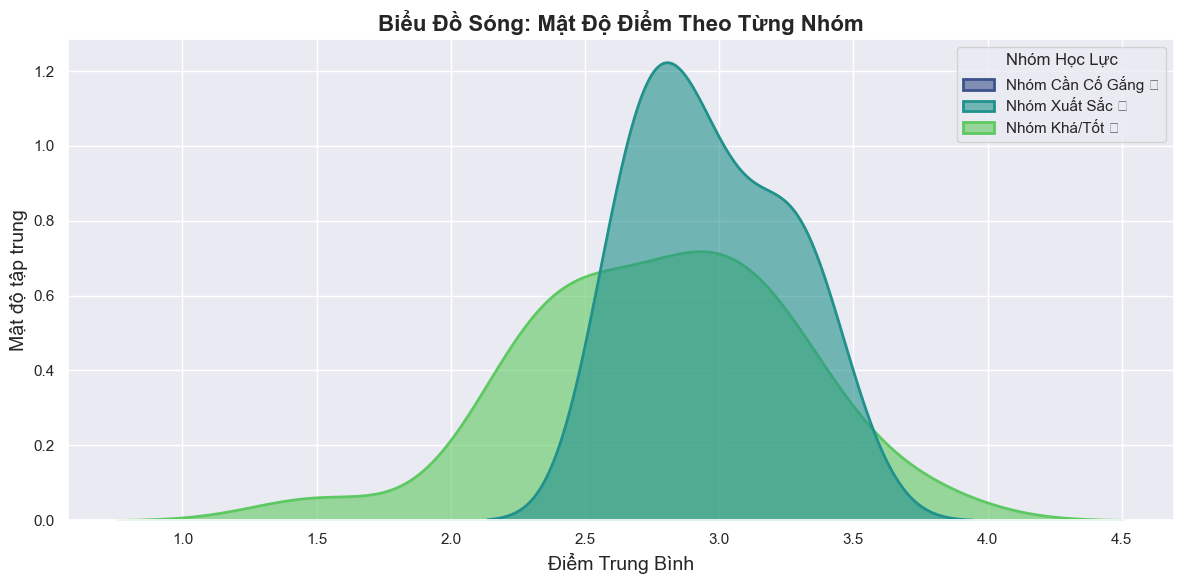

📸 Đã lưu Biểu đồ 2: Density Plot


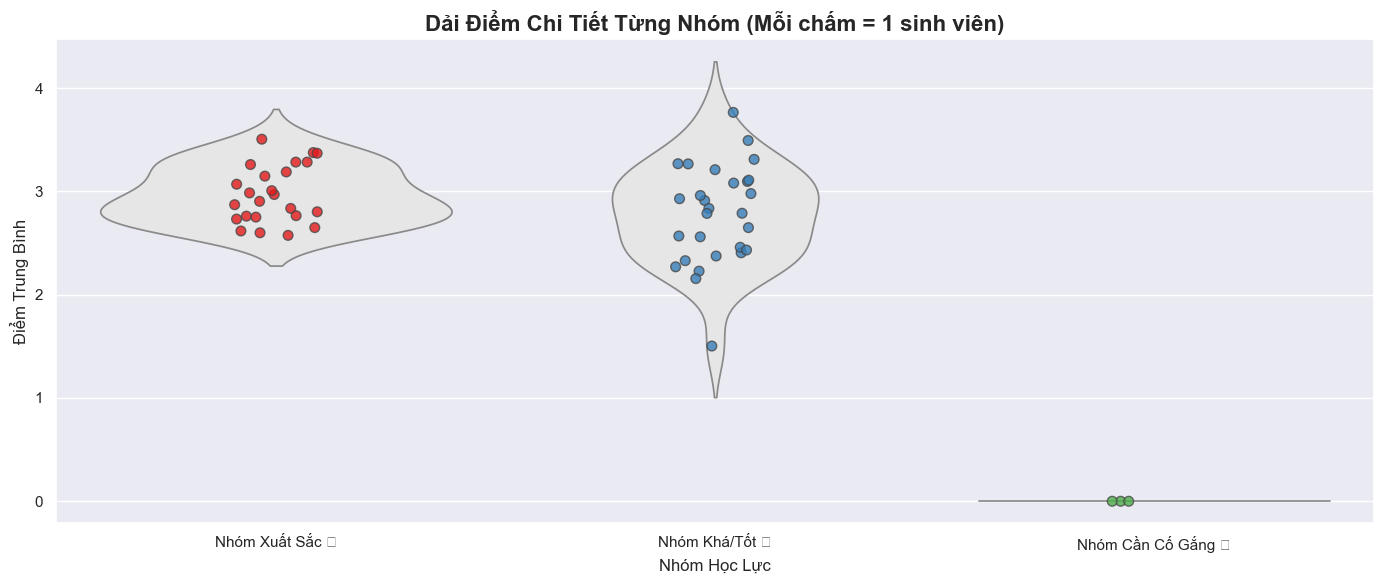

📸 Đã lưu Biểu đồ 3: Violin & Strip


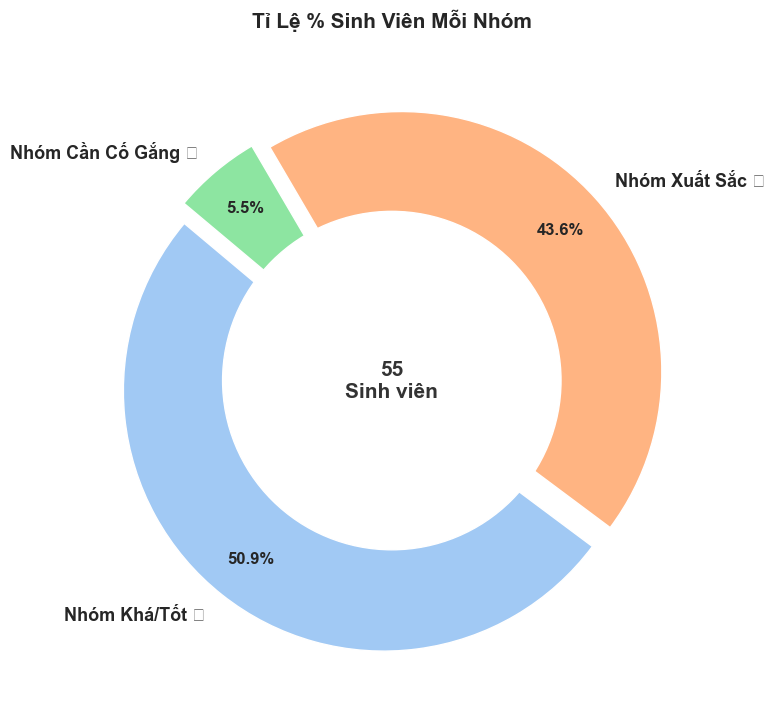

📸 Đã lưu Biểu đồ 4: Donut Chart

✅ Đã lưu đủ 4/4 biểu đồ:
  chart1: chart1_dendrogram.png — Tồn tại: True
  chart2: chart2_density.png — Tồn tại: True
  chart3: chart3_violin.png — Tồn tại: True
  chart4: chart4_donut.png — Tồn tại: True


In [14]:
# BƯỚC 4: VẼ VÀ LƯU TẤT CẢ 4 BIỂU ĐỒ (1 CELL DUY NHẤT)
order3 = ['Nhóm Xuất Sắc 🥇','Nhóm Khá/Tốt 🥈','Nhóm Cần Cố Gắng 🥉']
grp_clr = {'Nhóm Xuất Sắc 🥇':'#2ecc71','Nhóm Khá/Tốt 🥈':'#f1c40f','Nhóm Cần Cố Gắng 🥉':'#e74c3c'}
chart_paths = {}

# ── Biểu đồ 1: DENDROGRAM ──
fig, ax = plt.subplots(figsize=(15,7))
ax.set_title('Biểu Đồ Dendrogram — Phân Tầng Năng Lực Sinh Viên', fontsize=18, fontweight='bold')
ax.set_xlabel('Cụm Sinh Viên', fontsize=12); ax.set_ylabel('Khoảng Cách', fontsize=12)
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90., leaf_font_size=10., show_contracted=True, color_threshold=Z[-3,2], ax=ax)
ax.axhline(y=Z[-3,2], c='red', ls='--', lw=2, label='Ranh giới 3 nhóm')
ax.legend(fontsize=11); plt.tight_layout()
fig.savefig('chart1_dendrogram.png', dpi=150, bbox_inches='tight')
chart_paths['chart1'] = 'chart1_dendrogram.png'
plt.show(); plt.close(fig)
print('📸 Đã lưu Biểu đồ 1: Dendrogram')

# ── Biểu đồ 2: DENSITY PLOT ──
fig, ax = plt.subplots(figsize=(12,6))
sns.kdeplot(data=df_clean, x='Điểm Trung Bình', hue='Nhóm Học Lực', fill=True, common_norm=False, palette='viridis', alpha=.6, linewidth=2, ax=ax)
ax.set_title('Biểu Đồ Sóng: Mật Độ Điểm Theo Từng Nhóm', fontsize=16, fontweight='bold')
ax.set_xlabel('Điểm Trung Bình', fontsize=14); ax.set_ylabel('Mật độ tập trung', fontsize=14)
plt.tight_layout()
fig.savefig('chart2_density.png', dpi=150, bbox_inches='tight')
chart_paths['chart2'] = 'chart2_density.png'
plt.show(); plt.close(fig)
print('📸 Đã lưu Biểu đồ 2: Density Plot')

# ── Biểu đồ 3: VIOLIN + STRIP ──
fig, ax = plt.subplots(figsize=(14,6))
sns.violinplot(x='Nhóm Học Lực', y='Điểm Trung Bình', data=df_clean, order=order3, inner=None, color='.9', ax=ax)
sns.stripplot(x='Nhóm Học Lực', y='Điểm Trung Bình', data=df_clean, order=order3, size=7, jitter=True, palette='Set1', alpha=0.8, linewidth=1, ax=ax)
ax.set_title('Dải Điểm Chi Tiết Từng Nhóm (Mỗi chấm = 1 sinh viên)', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig('chart3_violin.png', dpi=150, bbox_inches='tight')
chart_paths['chart3'] = 'chart3_violin.png'
plt.show(); plt.close(fig)
print('📸 Đã lưu Biểu đồ 3: Violin & Strip')

# ── Biểu đồ 4: DONUT CHART ──
fig, ax = plt.subplots(figsize=(8,8))
grp = df_clean['Nhóm Học Lực'].value_counts()
colors_pie = sns.color_palette('pastel')[0:len(grp)]
wedges, texts, autotexts = ax.pie(grp, labels=grp.index, colors=colors_pie, autopct='%1.1f%%', startangle=140, pctdistance=0.82, explode=[0.05]*len(grp), textprops={'fontsize':13,'fontweight':'bold'})
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax.add_artist(plt.Circle((0,0), 0.65, fc='white'))
ax.text(0, 0, f'{len(df_clean)}\nSinh viên', ha='center', va='center', fontsize=15, fontweight='bold', color='#333')
ax.set_title('Tỉ Lệ % Sinh Viên Mỗi Nhóm', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
fig.savefig('chart4_donut.png', dpi=150, bbox_inches='tight')
chart_paths['chart4'] = 'chart4_donut.png'
plt.show(); plt.close(fig)
print('📸 Đã lưu Biểu đồ 4: Donut Chart')

print(f'\n✅ Đã lưu đủ {len(chart_paths)}/4 biểu đồ:')
for k,v in chart_paths.items():
    print(f'  {k}: {v} — Tồn tại: {os.path.exists(v)}')

In [15]:
# BƯỚC 5: XUẤT EXCEL 3 SHEET
output_file = 'KetQua_PhanCum_DayDu.xlsx'
try:
    wb = openpyxl.Workbook()
    bd = Border(left=Side(style='thin'),right=Side(style='thin'),top=Side(style='thin'),bottom=Side(style='thin'))
    gcol = {'Nhóm Xuất Sắc 🥇':'C6EFCE','Nhóm Khá/Tốt 🥈':'FFEB9C','Nhóm Cần Cố Gắng 🥉':'FFC7CE'}

    # ── SHEET 1: DỮ LIỆU ĐẦY ĐỦ ──
    ws1 = wb.active; ws1.title = 'Kết Quả Phân Cụm'
    nc = df_clean.shape[1]
    ws1.merge_cells(f'A1:{get_column_letter(min(nc,10))}1')
    t = ws1['A1']
    t.value = '🎓 KẾT QUẢ PHÂN CỤM HỌC LỰC SINH VIÊN — K58KTP'
    t.font = Font(bold=True, size=15, color='FFFFFF')
    t.fill = PatternFill(start_color='2E4057', end_color='2E4057', fill_type='solid')
    t.alignment = Alignment(horizontal='center', vertical='center')
    ws1.row_dimensions[1].height = 38
    for ri, row in enumerate(dataframe_to_rows(df_clean, index=False, header=True), start=3):
        for ci, val in enumerate(row, start=1):
            c = ws1.cell(row=ri, column=ci, value=val)
            c.border = bd; c.alignment = Alignment(horizontal='center', vertical='center')
            if ri == 3:
                c.font = Font(bold=True, size=11, color='FFFFFF')
                c.fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
            else:
                nhom = ws1.cell(row=ri, column=1).value
                if nhom in gcol:
                    c.fill = PatternFill(start_color=gcol[nhom], end_color=gcol[nhom], fill_type='solid')
    for ci in range(1, nc+1):
        cl = get_column_letter(ci)
        mx = max((len(str(ws1.cell(row=r,column=ci).value or '')) for r in range(3, ws1.max_row+1)), default=10)
        ws1.column_dimensions[cl].width = min(mx+4, 35)
    print('✅ Sheet 1 xong!')

    # ── SHEET 2: 4 BIỂU ĐỒ ──
    ws2 = wb.create_sheet(title='Biểu Đồ')
    ws2.merge_cells('A1:P1')
    h = ws2['A1']
    h.value = '📊 TOÀN BỘ BIỂU ĐỒ PHÂN TÍCH HỌC LỰC SINH VIÊN'
    h.font = Font(bold=True, size=15, color='FFFFFF')
    h.fill = PatternFill(start_color='2E4057', end_color='2E4057', fill_type='solid')
    h.alignment = Alignment(horizontal='center', vertical='center')
    ws2.row_dimensions[1].height = 35

    chart_info = [
        ('chart1', 'A3',   'Biểu Đồ 1: Dendrogram — Cây Phân Cấp Năng Lực'),
        ('chart2', 'A36',  'Biểu Đồ 2: Sóng Mật Độ Điểm Theo Nhóm'),
        ('chart3', 'A69',  'Biểu Đồ 3: Violin — Dải Điểm Từng Sinh Viên'),
        ('chart4', 'A102', 'Biểu Đồ 4: Tỉ Lệ % Sinh Viên (Donut Chart)'),
    ]
    for key, anchor, label in chart_info:
        fpath = chart_paths.get(key,'')
        if fpath and os.path.exists(fpath):
            rn = int(''.join(filter(str.isdigit, anchor)))
            lc = ws2.cell(row=rn-1, column=1, value=label)
            lc.font = Font(bold=True, size=13, color='2E4057')
            img = XLImage(fpath)
            img.width = 950; img.height = 430
            ws2.add_image(img, anchor)
            print(f'  ✅ Nhúng: {label}')
        else:
            print(f'  ⚠️ THIẾU FILE ẢNH cho {key}: "{fpath}"')
    print('✅ Sheet 2 xong!')

    # ── SHEET 3: THỐNG KÊ ──
    ws3 = wb.create_sheet(title='Thống Kê')
    ws3.merge_cells('A1:E1')
    s = ws3['A1']
    s.value = '📋 BẢNG THỐNG KÊ TÓM TẮT TỪNG NHÓM'
    s.font = Font(bold=True, size=14, color='FFFFFF')
    s.fill = PatternFill(start_color='2E4057', end_color='2E4057', fill_type='solid')
    s.alignment = Alignment(horizontal='center', vertical='center')
    ws3.row_dimensions[1].height = 35
    hdrs = ['Nhóm Học Lực','Số lượng SV','Tỉ lệ (%)','Điểm TB Min','Điểm TB Max']
    for ci, h in enumerate(hdrs, 1):
        c = ws3.cell(row=3, column=ci, value=h)
        c.font = Font(bold=True, color='FFFFFF')
        c.fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
        c.alignment = Alignment(horizontal='center'); c.border = bd
    for ri, (gn, gc) in enumerate(gcol.items(), 4):
        sub = df_clean[df_clean['Nhóm Học Lực']==gn]
        cnt = len(sub); pct = round(cnt/len(df_clean)*100,1)
        dmin = round(sub['Điểm Trung Bình'].min(),2) if cnt>0 else 0
        dmax = round(sub['Điểm Trung Bình'].max(),2) if cnt>0 else 0
        for ci, v in enumerate([gn, cnt, f'{pct}%', dmin, dmax], 1):
            c = ws3.cell(row=ri, column=ci, value=v)
            c.fill = PatternFill(start_color=gc, end_color=gc, fill_type='solid')
            c.alignment = Alignment(horizontal='center')
            c.border = bd; c.font = Font(bold=True)
    for ci in range(1, len(hdrs)+1):
        ws3.column_dimensions[get_column_letter(ci)].width = 28
    print('✅ Sheet 3 xong!')

    wb.save(output_file)
    print(f'\n🎉 XUẤT THÀNH CÔNG: "{output_file}"')
    print('  📊 Sheet 1: Bảng dữ liệu đầy đủ tên SV + tô màu theo nhóm')
    print('  📈 Sheet 2: 4 biểu đồ nhúng sẵn')
    print('  📋 Sheet 3: Bảng thống kê tóm tắt')
except Exception as e:
    import traceback; print(f'❌ Lỗi: {e}'); traceback.print_exc()

✅ Sheet 1 xong!
  ✅ Nhúng: Biểu Đồ 1: Dendrogram — Cây Phân Cấp Năng Lực
  ✅ Nhúng: Biểu Đồ 2: Sóng Mật Độ Điểm Theo Nhóm
  ✅ Nhúng: Biểu Đồ 3: Violin — Dải Điểm Từng Sinh Viên
  ✅ Nhúng: Biểu Đồ 4: Tỉ Lệ % Sinh Viên (Donut Chart)
✅ Sheet 2 xong!
✅ Sheet 3 xong!

🎉 XUẤT THÀNH CÔNG: "KetQua_PhanCum_DayDu.xlsx"
  📊 Sheet 1: Bảng dữ liệu đầy đủ tên SV + tô màu theo nhóm
  📈 Sheet 2: 4 biểu đồ nhúng sẵn
  📋 Sheet 3: Bảng thống kê tóm tắt
